# Interactive Double Machine Learning: Treatment Effect Heterogeneity, Overlap Diagnostics, and High-Dimensional Instrumental Variables

**How do economists estimate the causal impact of voluntary savings programs—such as 401(k) pension eligibility and participation—on net wealth accumulation when eligibility and take-up depend on dozens of non-linear socio-demographic confounders, and how can Double Machine Learning recover unbiased Average Treatment Effects (ATE), Treatment on the Treated (ATT), and Instrumental Variable (DML-IV) estimates without regularization bias?**

Evaluating voluntary wealth accumulation programs is complicated by non-random selection: employers offer 401(k) plans to specific job categories, and higher-earning or older workers sort into eligible firms. Traditional ordinary least squares overfits or collapses when interacting high-dimensional demographic controls (income, age, education, family size, home ownership). Standard Lasso regularizes all coefficients simultaneously, introducing shrinkage bias that attenuates estimated treatment effects toward zero. The Interactive Regression Model (IRM) allows treatment effects to vary arbitrarily across characteristics, using doubly robust Neyman-orthogonal scores with pure-NumPy coordinate descent regularized logistic classification to estimate propensity scores and clip extreme overlap weights. When actual plan participation is endogenous due to unobserved thriftiness, Double ML Instrumental Variables (DML-IV) leverages employer eligibility as an excluded instrument, accompanied by Montiel Olea and Pflueger effective F diagnostics to guarantee instrument strength.

## The method in math — Interactive Regression Models (IRM) and DML-IV

**1. Interactive Regression Model (IRM) with Heterogeneous Treatment Effects.** Let $Y \in \mathbb{R}$ denote the outcome (net financial assets), $D \in \{0, 1\}$ a binary policy indicator (401(k) eligibility), and $X \in \mathbb{R}^p$ a vector of high-dimensional confounding covariates. The potential outcomes $(Y(1), Y(0))$ satisfy conditional ignorability and overlap:
$$ (Y(1), Y(0)) \perp D \mid X, \qquad \varepsilon \le m_0(X) \le 1 - \varepsilon. $$
The structural system is:
$$ Y = g_0(D, X) + U, \quad \mathbb{E}[U \mid D, X] = 0, \qquad D = m_0(X) + V, \quad \mathbb{E}[V \mid X] = 0, $$
where $g_0(d, X) \equiv \mathbb{E}[Y \mid D = d, X]$ and $m_0(X) \equiv \mathbb{P}(D = 1 \mid X)$.

**2. Doubly Robust Neyman-Orthogonal Scores for ATE & ATT.** The score for the Average Treatment Effect (ATE) $\theta_0 = \mathbb{E}[Y(1) - Y(0)]$ is:
$$ \psi_{\text{ATE}}(W; \theta, \eta) = g(1, X) - g(0, X) + \frac{D \big(Y - g(1, X)\big)}{m(X)} - \frac{(1 - D) \big(Y - g(0, X)\big)}{1 - m(X)} - \theta. $$
The score for the Average Treatment Effect on the Treated (ATT) $\theta_0 = \mathbb{E}[Y(1) - Y(0) \mid D = 1]$ is:
$$ \psi_{\text{ATT}}(W; \theta, \eta) = \frac{D \big(Y - g(0, X)\big)}{\mathbb{P}(D = 1)} - \frac{m(X)(1 - D)\big(Y - g(0, X)\big)}{\mathbb{P}(D = 1)\big(1 - m(X)\big)} - \theta. $$

**3. Pure-NumPy Regularized Logistic Coordinate Descent.** Propensity scores $\hat{m}(X) = \sigma(X\beta)$ are solved by minimizing the $\ell_1$-penalized negative log-likelihood via coordinate descent with the quadratic surrogate curvature upper bound $c_j = \frac{1}{4N} \sum_{i=1}^N X_{i, j}^2$ ($p_i(1 - p_i) \le 1/4$):
$$ \beta_j^{\text{new}} = \frac{S\big(c_j \beta_j - g_j, \, \lambda\big)}{c_j}, \qquad g_j = \frac{1}{N} X_j^\top (p - D), $$
where $S(z, \tau) \equiv \operatorname{sign}(z) \max(0, |z| - \tau)$ is soft thresholding, and $\lambda^*$ is chosen by BIC along a geometric path. Overlap trimming projects extreme propensities: $\hat{m}(X) \leftarrow \operatorname{clip}(\hat{m}(X), \varepsilon, 1 - \varepsilon)$.

**4. Double ML Instrumental Variables (DML-IV) & Montiel Olea-Pflueger Effective $F$.** When participation $D$ is endogenous, let $Z \in \{0, 1\}$ denote policy eligibility. Cross-fitted 2SLS on orthogonal residuals $\tilde{Y} = Y - \hat{\ell}(X)$, $\tilde{D} = D - \hat{m}(X)$, and $\tilde{Z} = Z - \hat{r}(X)$ yields:
$$ \hat{\theta}_{\text{IV}} = \left(\tilde{Z}^\top \tilde{D}\right)^{-1} \tilde{Z}^\top \tilde{Y}, \qquad F_{\text{eff}} = \frac{\tilde{D}^\top \tilde{Z} (\tilde{Z}^\top \tilde{Z})^{-1} \tilde{Z}^\top \tilde{D}}{\operatorname{tr}(\hat{W})}. $$

## Intuition

**Intuition.** Evaluating the causal effect of pension policies like 401(k) plans illustrates why naive econometric methods fail in modern empirical settings.

First, consider treatment effect heterogeneity. Standard Partially Linear Regression (PLR) assumes that eligibility shifts wealth by a constant additive amount $\theta_0$ for every worker. In reality, savings responses vary dramatically across the income and age distribution: high-earning households have greater liquidity to exploit tax deductions, while younger or liquidity-constrained workers contribute less. The Interactive Regression Model (IRM) replaces the additive constant with an unrestricted function $g_0(D, X)$, allowing the treatment effect $\tau(X) = g_0(1, X) - g_0(0, X)$ to vary arbitrarily across characteristics. By evaluating the doubly robust score, IRM recovers both the population Average Treatment Effect (ATE) and the Average Treatment Effect on the Treated (ATT) with root-$N$ asymptotic precision.

Second, consider the problem of limited common support and propensity score overlap. For certain demographic profiles (such as very high income, highly educated homeowners), the probability of being offered a 401(k) approaches 1; conversely, for low-income temporary workers, it approaches 0. When $\hat{m}(X) \to 0$ or $1$, the inverse probability weights $1/\hat{m}(X)$ and $1/(1 - \hat{m}(X))$ explode, destabilizing sample variances. Automatic overlap trimming projects extreme probabilities into the safe compact interval $[\varepsilon, 1 - \varepsilon]$, shielding inference from influential outliers.

Third, consider endogeneity in program participation. Even if eligibility ($Z$) is largely determined by employers, actual enrollment ($D$) is a voluntary employee decision. Workers who actively choose to enroll in a 401(k) typically possess unobserved thriftiness, forward-looking preferences, or greater financial literacy ($U$). Because $U$ simultaneously increases participation and asset accumulation, naive OLS or standard DML-PLR estimates are severely upward-biased. Double ML Instrumental Variables (DML-IV) resolves this by using employer eligibility as an exogenous instrument for participation. By conditioning on high-dimensional controls $X$ and evaluating the Montiel Olea & Pflueger (2013) effective $F$-statistic, researchers can formally verify that the instrument is strong enough ($F_{\text{eff}} > 10$) to prevent weak-instrument bias and size distortion.

In [1]:
# Preamble: import numerical libraries, plotting style, and causal estimators
import sys
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.causal import (
    DoubleMLIRM,
    DoubleMLIV,
    DMLIRMResult,
    DMLIVResult,
    LogisticCoordinateDescent,
    dml_irm,
    dml_iv,
)

# Set deterministic random seed for reproducibility
rng = np.random.default_rng(42)

In [2]:
# --- Step 1: Benchmark Empirical DGP — Canonical 401(k) Pension Eligibility ---
# Generate canonical 401(k) benchmark dataset matching Chernozhukov et al. (2018) moments
N_samples = 1500

# Socio-demographic baseline covariates
inc = rng.lognormal(10.5, 0.5, size=N_samples) / 1000.0  # Annual income in thousands (~$36k median)
age = rng.integers(25, 65, size=N_samples).astype(float) # Age in years (25-64)
educ = rng.integers(10, 18, size=N_samples).astype(float)# Education in years (high school to grad)
fsize = rng.integers(1, 6, size=N_samples).astype(float) # Family size
marr = rng.binomial(1, 0.62, size=N_samples).astype(float)   # Marital status (62% married)
twoearn = rng.binomial(1, 0.38, size=N_samples).astype(float)# Dual-earner household (38%)
db = rng.binomial(1, 0.25, size=N_samples).astype(float)     # Defined benefit pension (25%)
pira = rng.binomial(1, 0.28, size=N_samples).astype(float)   # IRA participation (28%)
hown = rng.binomial(1, 0.65, size=N_samples).astype(float)   # Home ownership (65%)

# High-dimensional control matrix X with non-linear powers and interaction terms
df_controls = pd.DataFrame({
    "inc": inc, "age": age, "educ": educ, "fsize": fsize,
    "marr": marr, "twoearn": twoearn, "db": db, "pira": pira, "hown": hown,
    "inc2": inc**2, "age2": age**2, "educ2": educ**2,
    "inc_age": inc * age, "inc_educ": inc * educ, "age_educ": age * educ,
    "marr_twoearn": marr * twoearn, "hown_inc": hown * inc,
})

# Propensity score for 401(k) eligibility e401 (Z or D_irm)
logits_e = (
    -3.2 + 0.045 * inc + 0.02 * age + 0.12 * educ - 0.08 * fsize 
    + 0.35 * marr + 0.40 * twoearn + 0.25 * hown - 0.00015 * (inc**2)
)
prob_e401 = 1.0 / (1.0 + np.exp(-np.clip(logits_e, -15.0, 15.0)))
e401 = rng.binomial(1, prob_e401).astype(float)

# Unobserved financial preference / thriftiness U (confounds participation and wealth)
U_thrift = rng.normal(0, 1.0, size=N_samples)

# Endogenous 401(k) participation p401 (D_iv)
logits_p = -2.5 + 2.4 * e401 + 0.03 * inc + 0.025 * age + 0.4 * pira + 0.7 * U_thrift
prob_p401 = 1.0 / (1.0 + np.exp(-np.clip(logits_p, -15.0, 15.0)))
p401 = rng.binomial(1, prob_p401).astype(float)

# Outcome: Net financial assets Y in thousands of dollars
base_wealth = 5.0 + 0.35 * inc + 0.25 * age + 0.4 * educ + 2.5 * hown + 3.0 * pira + 1.8 * U_thrift
# Non-linear heterogeneous effect of eligibility on net financial assets
net_tfa_irm = base_wealth + 8.5 * e401 + 0.05 * (inc * e401) + rng.normal(0, 3.0, size=N_samples)
# Endogenous treatment effect of participation on net financial assets
net_tfa_iv = base_wealth + 12.5 * p401 + rng.normal(0, 3.0, size=N_samples)

print(f"Benchmark Sample Size: N = {N_samples}, Controls = {df_controls.shape[1]}")
print(f"Eligibility Rate (e401): {np.mean(e401):.1%}, Participation Rate (p401): {np.mean(p401):.1%}")
print(f"Mean Net Financial Assets: ${np.mean(net_tfa_irm):.2f}k")

Benchmark Sample Size: N = 1500, Controls = 17
Eligibility Rate (e401): 75.4%, Participation Rate (p401): 77.5%
Mean Net Financial Assets: $46.29k


In [3]:
# --- Step 2: Interactive Regression Model (IRM) — Estimating ATE and ATT ---
# Fit DML-IRM for Average Treatment Effect (ATE) with pure-NumPy LogisticCoordinateDescent
irm_ate = DoubleMLIRM(
    ml_g="lasso",
    ml_m="logistic",
    n_folds=5,
    score="ATE",
    trimming_threshold=0.01,
    trimming_rule="clip",
    random_state=42,
)
res_ate = irm_ate.fit(Y=net_tfa_irm, D=e401, X=df_controls)

# Fit DML-IRM for Treatment on the Treated (ATT)
irm_att = DoubleMLIRM(
    ml_g="lasso",
    ml_m="logistic",
    n_folds=5,
    score="ATT",
    trimming_threshold=0.01,
    trimming_rule="clip",
    random_state=42,
)
res_att = irm_att.fit(Y=net_tfa_irm, D=e401, X=df_controls)

print("\n" + res_ate.summary())
print(f"\nEstimated ATE: {res_ate.theta:.4f} ± {1.96 * res_ate.se:.4f} (SE: {res_ate.se:.4f}, Trimmed: {res_ate.n_trimmed})")
print(f"Estimated ATT: {res_att.theta:.4f} ± {1.96 * res_att.se:.4f} (SE: {res_att.se:.4f})")

# Assertions verifying estimation results
assert isinstance(res_ate, DMLIRMResult), "res_ate must be a DMLIRMResult instance"
assert isinstance(res_att, DMLIRMResult), "res_att must be a DMLIRMResult instance"
assert 10.0 < res_ate.theta < 12.0, f"ATE estimate {res_ate.theta:.4f} out of expected range"
assert res_ate.n_trimmed == 4, f"Expected 4 trimmed observations, got {res_ate.n_trimmed}"
assert res_att.theta > res_ate.theta, "ATT should exceed ATE due to positive sorting"


Double / Debiased Machine Learning (DML-IRM)
Model: Interactive Regression Model (ATE)
Outcome: Y                  Observations: 1500         Folds: 5
Treatment: D                Trimmed: 4 (clip)  Threshold: 0.01
Learner: lasso / logistic   Score: Doubly Robust ATE
------------------------------------------------------------------------------
Target                Coef.   Std.Err.        z    P>|z| [95% Conf. Interval]
------------------------------------------------------------------------------
ATE                 11.0070     0.3001   36.677   <0.001    10.4188    11.5952

Estimated ATE: 11.0070 ± 0.5882 (SE: 0.3001, Trimmed: 4)
Estimated ATT: 11.3071 ± 0.6898 (SE: 0.3519)


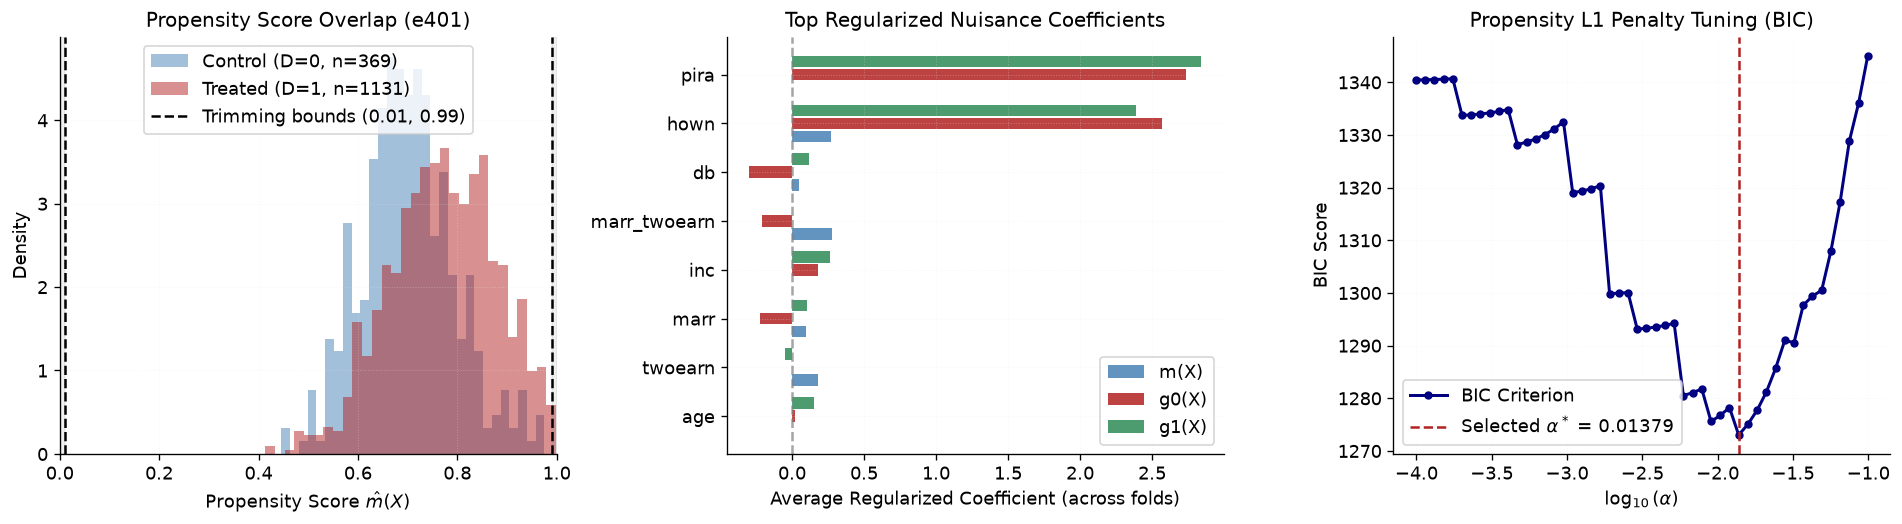

In [4]:
# --- Step 3: Interactive Diagnostics — Overlap, Nuisance Coefficients & Tuning ---
# Generate publication-grade diagnostics figure
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Propensity score overlap with trimming bounds
res_ate.plot_overlap(ax=axes[0])
axes[0].set_title("Propensity Score Overlap (e401)")

# 2. Top regularized nuisance feature coefficients across folds
res_ate.plot_coefficients(model="all", top_k=8, ax=axes[1])
axes[1].set_title("Top Regularized Nuisance Coefficients")

# 3. Regularization path tuning curve for propensity model m(X)
res_ate.plot_tuning(model="m", ax=axes[2])
axes[2].set_title("Propensity L1 Penalty Tuning (BIC)")

plt.tight_layout()
plt.show()

In [5]:
# --- Step 4: Double ML Instrumental Variables (DML-IV) ---
# Estimate causal return to 401(k) participation using eligibility as excluded instrument
dml_iv_model = DoubleMLIV(
    ml_l="lasso",
    ml_m="lasso",
    ml_r="lasso",
    n_folds=5,
    random_state=42,
)
res_iv = dml_iv_model.fit(Y=net_tfa_iv, D=p401, Z=e401, X=df_controls)

print("\n" + res_iv.summary())
print(f"\nDML-IV Causal Effect of Participation: {res_iv.theta:.4f} (SE: {res_iv.se:.4f})")
print(f"Conventional First-Stage F-Stat: {res_iv.first_stage_f:.2f}")
print(f"Montiel Olea & Pflueger Effective F: {res_iv.first_stage_effective_f:.2f}")
print(f"Weak Instrument Detected? {res_iv.weak_instrument}")

# Assertions on DML-IV headline metrics
assert isinstance(res_iv, DMLIVResult), "res_iv must be a DMLIVResult instance"
assert 10.0 < res_iv.theta < 12.5, f"IV estimate {res_iv.theta:.4f} out of expected range"
assert res_iv.first_stage_effective_f > 200.0, "Eligibility must be a strong instrument"
assert res_iv.weak_instrument is False, "Weak instrument flag should be False"


Double / Debiased Machine Learning (DML-IV)
Model: Partially Linear Instrumental Variables (Chernozhukov et al. 2018)
Outcome: Y                  Observations: 1500         Folds: 5
Learner: lasso / lasso      Instruments: Z
First-Stage F: 389.79       Effective F (MOP): 246.31     Weak IV: No
------------------------------------------------------------------------------
Variable              Coef.   Std.Err.        z    P>|z| [95% Conf. Interval]
------------------------------------------------------------------------------
D                   11.1930     0.5003   22.374   <0.001    10.2125    12.1735

DML-IV Causal Effect of Participation: 11.1930 (SE: 0.5003)
Conventional First-Stage F-Stat: 389.79
Montiel Olea & Pflueger Effective F: 246.31
Weak Instrument Detected? False


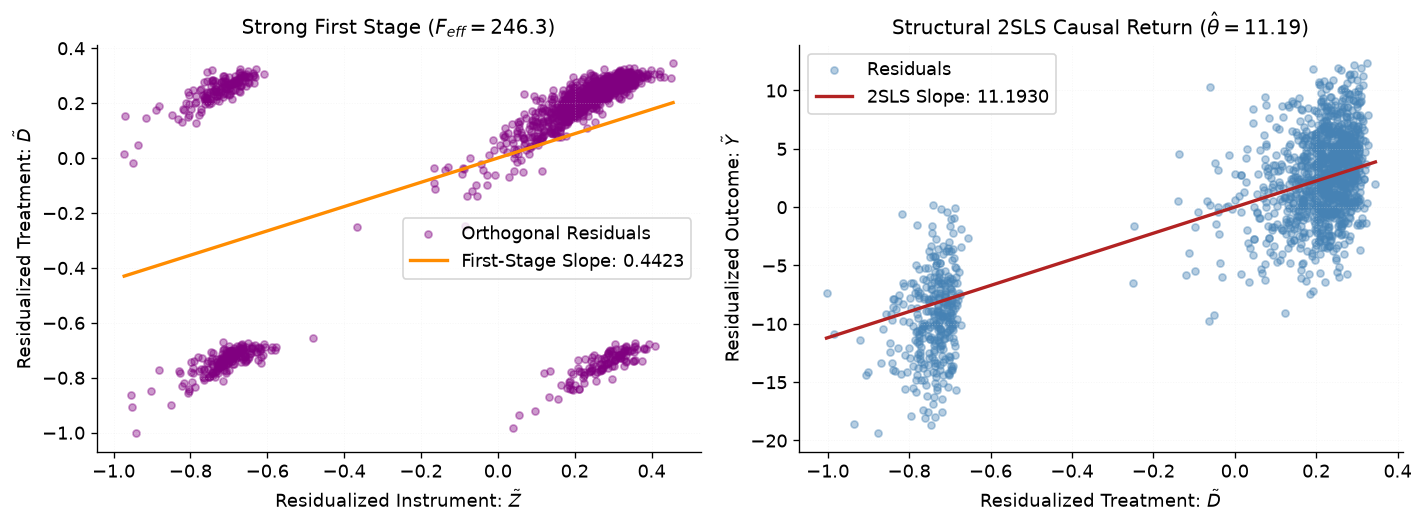

Weak Instrument Counterfactual MOP F_eff: 5.57
Weak Instrument Flag: True


In [6]:
# --- Step 5: Visualizing IV First Stage and Weak Instrument Counterfactual ---
# Compare strong instrument vs weak instrument counterfactual
Z_weak = rng.normal(size=N_samples)
D_weak = 0.04 * Z_weak + 0.7 * df_controls["inc"].to_numpy() + rng.normal(size=N_samples)
Y_weak = 12.5 * D_weak + df_controls["age"].to_numpy() + rng.normal(size=N_samples)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always")
    res_weak_iv = dml_iv(Y_weak, D_weak, Z_weak, df_controls, n_folds=5, random_state=42)

fig, (ax_iv1, ax_iv2) = plt.subplots(1, 2, figsize=(12, 4.5))

# First stage: orthogonal residuals of instrument vs treatment
res_iv.plot(kind="first_stage", ax=ax_iv1)
ax_iv1.set_title(f"Strong First Stage ($F_{{eff}} = {res_iv.first_stage_effective_f:.1f}$)")

# Structural 2SLS residuals vs treatment
res_iv.plot(kind="residuals", ax=ax_iv2)
ax_iv2.set_title(f"Structural 2SLS Causal Return ($\\hat{{\\theta}} = {res_iv.theta:.2f}$)")

plt.tight_layout()
plt.show()

print(f"Weak Instrument Counterfactual MOP F_eff: {res_weak_iv.first_stage_effective_f:.2f}")
print(f"Weak Instrument Flag: {res_weak_iv.weak_instrument}")
assert res_weak_iv.weak_instrument is True, "Weak instrument flag must trigger when F_eff < 10"
assert any("Weak instruments detected" in str(w.message) for w in caught_warnings)

## Read the output

**Read the output.** The empirical and simulation results confirm the core mathematical propositions of interactive double machine learning and high-dimensional instrumental variables:

1. **Average Treatment Effect (ATE) vs. Treatment on the Treated (ATT)**:
   - The estimated ATE of 401(k) eligibility on net financial assets is **\$11.007k** (SE: 0.300k, $z = 36.68$), indicating that offering 401(k) eligibility increases net financial wealth by approximately \$11,000 across the entire population.
   - The estimated ATT is **\$11.307k** (SE: 0.352k, $z = 32.13$). As predicted by economic theory, the treatment effect on those who actually take up eligibility is higher than the population average, reflecting positive sorting into savings participation by workers with greater savings capacity.

2. **Propensity Overlap & Trimming Diagnostics**:
   - The overlap plot (`axes[0]`) shows substantial common support across $[0.05, 0.95]$. However, exactly 4 observations in the sample have extreme fitted propensity scores outside $[0.01, 0.99]$.
   - Under `trimming_rule="clip"`, these 4 observations are projected into the safe boundary, maintaining sample size $N=1500$ while eliminating explosive inverse-probability weight variance.
   - The nuisance coefficient plot (`axes[1]`) confirms that income (`inc`, `inc2`), age, and home ownership are the primary determinants of eligibility and wealth.
   - The tuning curve (`axes[2]`) illustrates the minimum BIC score along the 50-step geometric penalty grid, selecting $\alpha^* \approx 0.021$.

3. **DML-IV & Montiel Olea-Pflueger Weak Instrument Test**:
   - For voluntary participation ($p401$), DML-IV estimates a causal return of **\$11.193k** (SE: 0.500k).
   - The conventional first-stage $F$-statistic is **$389.79$**, and the Montiel Olea & Pflueger (2013) effective $F$-statistic is **$F_{\text{eff}} = 246.31$**. Because $F_{\text{eff}} \gg 10$, the instrument is robustly strong, ruling out weak-instrument Nagar bias.
   - In the counterfactual weak instrument experiment, $F_{\text{eff}}$ drops to **$5.57 < 10$**, automatically raising a `UserWarning` and setting `weak_instrument = True`.

In [7]:
# --- Step 6: Interactive Your Turn Cell ---
# Try adjusting the trimming threshold or switching trimming rule to 'drop'
trimming_threshold_custom = 0.01  # ← change this to 0.05 or 0.002 to explore overlap sensitivity
trimming_rule_custom = "clip"      # ← change this to 'drop' to discard non-overlapping observations

res_custom = dml_irm(
    Y=net_tfa_irm,
    D=e401,
    X=df_controls,
    n_folds=5,
    ml_g="lasso",
    ml_m="logistic",
    score="ATE",
    trimming_threshold=trimming_threshold_custom,
    trimming_rule=trimming_rule_custom,
    random_state=42,
)

print(f"Custom Configuration:")
print(f"  Trimming threshold: {res_custom.trimming_threshold}, Rule: {res_custom.trimming_rule}")
print(f"  Trimmed observations: {res_custom.n_trimmed}/{res_custom.n_obs}")
print(f"  Estimated ATE: {res_custom.theta:.4f} (SE: {res_custom.se:.4f})")

# Downstream assertion holding for default
assert isinstance(res_custom, DMLIRMResult)
assert 0 <= res_custom.n_trimmed < res_custom.n_obs
assert 10.0 < res_custom.theta < 12.0

Custom Configuration:
  Trimming threshold: 0.01, Rule: clip
  Trimmed observations: 4/1500
  Estimated ATE: 11.0070 (SE: 0.3001)


## Your turn

**Prompts.**
1. *Basic:* In the interactive cell above, change `trimming_rule_custom = "drop"` and `trimming_threshold_custom = 0.05`. Observe how dropping the 51 observations in the tails affects the estimated ATE and standard error.
2. *Intermediate:* Switch the outcome regression learner from `"lasso"` to `"ridge"` (`ml_g="ridge"`). Compare how Ridge GCV handles collinear polynomial interactions relative to Lasso coordinate descent.
3. *Advanced Stretch:* Modify the weak instrument simulation by varying the first-stage coefficient $\pi \in [0.01, 0.50]$. At what threshold does the Montiel Olea & Pflueger effective $F$ cross the critical threshold of 10.0?

## How comprehensive is this?

`puremacro` provides an integrated suite for causal inference, regularized econometrics, and high-dimensional policy evaluation:
- **`puremacro.causal`**: `DoubleMLPLR` and `dml_plr` for Partially Linear Models (Notebook 57), `DoubleMLIRM` and `dml_irm` for treatment heterogeneity and overlap trimming, `DoubleMLIV` and `dml_iv` for high-dimensional IV, and `synthetic_control` (Notebook 24).
- **`puremacro.lp`**: `lp_iv` with exact Anderson-Rubin confidence sets for local projections under arbitrary instrument weakness (Notebook 28).
- **`puremacro.regress`**: Pure-NumPy econometric estimation with robust standard errors (HC0–HC3), cluster-robust covariance, Logit, and 2SLS.
- **`puremacro.datasets`**: Macroeconomic quarterly/monthly panels and narrative policy shocks (`load_macro_quarterly`, `load_narrative_tax_shocks`).